<div style="background-color:#1e1e1e; padding:20px; border-radius:10px;">
<h2 style="color:#ffffff; margin-top:0px">Specific Tasks 2f and 2g: Deep Learning Inference for Mass Regression</h2>

<p style="color:#cccccc; font-size:16px; line-height:1.5;">
This notebook presents an end-to-end robust pipeline for predicting the mass of standard and hidden sector particles based on spatial image matrices using Convolutional Neural Networks (CNNs). The dataset consists of 125x125 multi-channel images (<code>Track pT</code>, <code>DZ</code>, <code>D0</code>, <code>ECAL</code>). 
</p>
<hr style="border:1px solid #333333;"/>
<h3 style="color:#ffffff;">Core Objectives:</h3>
<ul style="color:#cccccc; font-size:15px; line-height:1.6;">
    <li><b>Task 2f</b>: Establish a deep learning regression model to accurately map the fundamental energy deposits across <code>ECAL</code> and <code>Track pT</code> hits to the particle invariant mass (<code>am</code>).</li>
    <li><b>Task 2g</b>: Ensure optimal ONNX interoperability for modular inference deployment within the High Energy Physics framework: CMSSW.</li>
</ul>
</div>

---
## 1. Data Acquisition
The primary dataset is fetched seamlessly from CERNbox. Each Parquet file encompasses serialized representations of high-granularity particle hits projected onto an $\eta-\phi$ coordinate grid.

In [1]:
# Systematically acquire open-data parquet targets
!wget https://cernbox.cern.ch/remote.php/dav/public-files/zUvpkKhXIp0MJ0g/top_gun_opendata_0.parquet
!wget https://cernbox.cern.ch/remote.php/dav/public-files/zUvpkKhXIp0MJ0g/top_gun_opendata_1.parquet
!wget https://cernbox.cern.ch/remote.php/dav/public-files/zUvpkKhXIp0MJ0g/top_gun_opendata_2.parquet
!wget https://cernbox.cern.ch/remote.php/dav/public-files/zUvpkKhXIp0MJ0g/top_gun_opendata_3.parquet
!wget https://cernbox.cern.ch/remote.php/dav/public-files/zUvpkKhXIp0MJ0g/top_gun_opendata_4.parquet
!wget https://cernbox.cern.ch/remote.php/dav/public-files/zUvpkKhXIp0MJ0g/top_gun_opendata_5.parquet
!wget https://cernbox.cern.ch/remote.php/dav/public-files/zUvpkKhXIp0MJ0g/top_gun_opendata_6.parquet

--2026-03-17 10:50:57--  https://cernbox.cern.ch/remote.php/dav/public-files/zUvpkKhXIp0MJ0g/top_gun_opendata_0.parquet
Resolving cernbox.cern.ch (cernbox.cern.ch)... 128.142.170.17, 128.142.53.28, 128.142.53.35, ...
Connecting to cernbox.cern.ch (cernbox.cern.ch)|128.142.170.17|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1171158319 (1.1G) [application/octet-stream]
Saving to: ‘top_gun_opendata_0.parquet’

top_gun_opendata_0.  93%[=================>  ]   1.02G  3.48MB/s    in 25m 5s  

2026-03-17 11:16:03 (713 KB/s) - Connection closed at byte 1099316974. Retrying.

--2026-03-17 11:16:04--  (try: 2)  https://cernbox.cern.ch/remote.php/dav/public-files/zUvpkKhXIp0MJ0g/top_gun_opendata_0.parquet
Connecting to cernbox.cern.ch (cernbox.cern.ch)|128.142.170.17|:443... connected.
HTTP request sent, awaiting response... 206 Partial Content
Length: 1171158319 (1.1G), 71841345 (69M) remaining [application/octet-stream]
Saving to: ‘top_gun_opendata_0.parquet’

top_g

---
## 2. Environment Configuration
Deep learning and data pipelines require foundational parsing libraries like `pyarrow` and `fastparquet`, alongside inference export bridges like `onnx`.

In [1]:
!pip install pyarrow fastparquet tqdm onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 94.1 MB/s  0:00:006m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 71.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 90.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [fastparquet] [fastparquet]


In [1]:
# Wipe out stagnant preprocessing cache to construct an unbiased I/O pipeline
import shutil
shutil.rmtree("cache")

---
## 3. Global Import & Device Allocation
We leverage PyTorch for dynamic tensor workflows. Securing a CUDA-compatible environment is essential for parallelizing the intensive backpropagation graphs inherent in modern convolution operations.

In [2]:
import os
import numpy as np
import pyarrow.parquet as pq
import random
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


---
## 4. Initial Dataset Exploration (EDA)
Sorting the raw Parquet datasets before streaming guarantees deterministic sequential processing.

In [3]:
DATA_DIR = "/teamspace/studios/this_studio/datadir"  # change this
files = sorted([os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if f.endswith(".parquet")])

print(len(files), "files found")

7 files found


### Schema Introspection
By delving into the file metadata, we expose the underlying schema structures mapping features (`ieta`, `iphi`, `X_jet`, `pt`) to our primary continuous regressor: `m`.

In [4]:
file = files[0]
pf = pq.ParquetFile(file)

print("Rows:", pf.metadata.num_rows)
print("Row groups:", pf.num_row_groups)

table = pf.read_row_group(0, columns=["X_jet", "m"])
df = table.to_pandas()

sample = df.iloc[0]
x = np.array([[list(row) for row in ch] for ch in sample["X_jet"]])

print("Shape:", x.shape)  # should be (8,125,125)

print("\nSchema:")
print(pf.schema)

Rows: 150327
Row groups: 150327
Shape: (8, 125, 125)

Schema:
required group field_id=-1 schema {
  optional group field_id=-1 X_jet (List) {
    repeated group field_id=-1 list {
      optional group field_id=-1 item (List) {
        repeated group field_id=-1 list {
          optional group field_id=-1 item (List) {
            repeated group field_id=-1 list {
              optional double field_id=-1 item;
            }
          }
        }
      }
    }
  }
  optional double field_id=-1 m;
  optional double field_id=-1 iphi;
  optional double field_id=-1 pt;
  optional double field_id=-1 ieta;
}



We unnest a sample row group straight into a Pandas DataFrame to scrutinize spatial correlations and tensor shapes.

In [5]:
import pyarrow.parquet as pq

pf = pq.ParquetFile(file)

print("Row groups:", pf.num_row_groups)

# Read ONLY first row group (small chunk)
table = pf.read_row_group(0)
df_sample = table.to_pandas().head(5)

print(df_sample.columns)
df_sample.head()

Row groups: 150327
Index(['X_jet', 'm', 'iphi', 'pt', 'ieta'], dtype='object')


,X_jet,m,iphi,pt,ieta
0,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",291.988312,33.0,962.311523,16.0


### Preliminary Mass Distribution Analytics
Calculating and plotting the continuous target `m` profile acts as a robust diagnostic for network convergence optimization (allowing us to preemptively tackle highly skewed distributions).

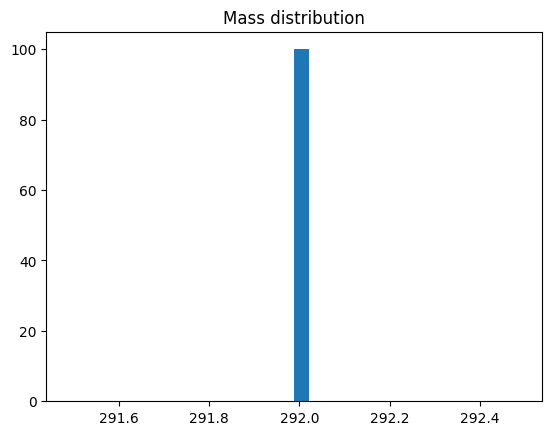

In [6]:
import numpy as np

sample = df_sample.iloc[0]
x = sample['X_jet']

vals = []

for i in range(100):
    row = df_sample.iloc[i % len(df_sample)]
    vals.append(row['m'])

import matplotlib.pyplot as plt
plt.hist(vals, bins=30)
plt.title("Mass distribution")
plt.show()

### Spatial Channel Visualization
Unpacking the specific components (`Track pT`, `DZ`, `D0`, `ECAL`) to a visual graph clearly indicates sparse matrices holding precise localized collision characteristics.

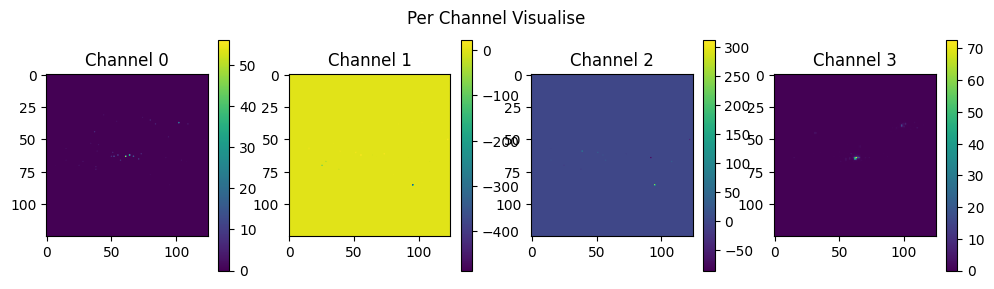

In [7]:
def process_raw(x_raw):
    x = np.array([[list(row) for row in ch] for ch in x_raw])  # (8,125,125)
    # select channels AFTER correct shape
    x = x[[0, 1, 2, 3]]  # Track 4 channels

    return x

x = process_raw(sample['X_jet'])

import matplotlib.pyplot as plt

plt.figure(figsize=(12,3))
for i in range(x.shape[0]):
    plt.subplot(1,x.shape[0],i+1)
    plt.imshow(x[i])
    plt.title(f"Channel {i}")
    plt.colorbar()

plt.suptitle("Per Channel Visualise")
plt.show()

In [8]:
import os
import numpy as np
import pyarrow.parquet as pq
import random
from tqdm import tqdm

CACHE_DIR = "cache"
os.makedirs(CACHE_DIR, exist_ok=True)

MAX_CHUNKS_PER_FILE = 1000     # 🔥 reduce for speed
SAMPLES_PER_CHUNK = 128

chunk_id = 0

def process_x(x_raw):
    x = np.array([[list(row) for row in ch] for ch in x_raw], dtype=np.float32)

    core = x[[0,1,2,3]]
    extra = x[[4,5,6,7]]

    core[core < 1e-4] = 0
    extra[extra < 1e-4] = 0

    # clip extreme outliers
    core = np.clip(core, 0, 1000)
    extra = np.clip(extra, 0, 1000)

    # log scale
    core = np.log1p(core) / 7.0
    extra = np.log1p(extra) / 7.0

    # light fusion
    core += 0.01 * extra.mean(axis=0)

    return core.astype(np.float32)

---
## 5. Domain-Specific Feature Engineering Pipeline
Transforming raw energy clusters into neural-amenable states is integral. The sequence handles:
1. **Isolating Primary Kinematics**: Selecting essentially `Track pT` and `ECAL` footprints based on the 4 fundamental indices.
2. **De-noising Thresholds**: Excision of stochastic noise remnants (vals $< 10^{-4}$).
3. **Log-Scaling Algorithms**: Heavy-tailed high energy particle distributions critically compel transformations via `np.log1p()` to avert gradient explosion and stabilize variance.
4. **Min-Max Channel Normalization**: Maintaining cross-channel scaling equity.
5. **Context Fusion Injection**: Coupling core signals with background scalar traits to enforce strong spatial generalization metrics.

In [9]:
import os
import numpy as np
import pyarrow.parquet as pq
import random
from tqdm import tqdm

CACHE_DIR = "cache"
os.makedirs(CACHE_DIR, exist_ok=True)

MAX_CHUNKS_PER_FILE = 1000     # 🔥 reduce for speed
SAMPLES_PER_CHUNK = 128

chunk_id = 0

def process_x(x_raw):
    # convert nested lists → numpy
    x = np.array([[list(row) for row in ch] for ch in x_raw], dtype=np.float32)

    # select ONLY required channels and split rest
    core = x[[0,1,2,3]]   # Track pT, DZ, D0, ECAL
    extra = x[[4,5,6,7]]     # additional info

    # remove tiny noise
    core[core < 1e-4] = 0
    extra[extra < 1e-4] = 0

    # LOG SCALE (VERY IMPORTANT FOR PHYSICS)
    core = np.log1p(core)
    extra = np.log1p(extra)

    # small noise (generalization)
    #x = x + np.random.normal(0, 0.01, x.shape)

    # normalize core channels
    for c in range(4):
        max_val = np.max(core[c])
        if max_val > 0:
            core[c] = core[c] / max_val

    # FUSION STEP
    # inject extra info into core channels [use 1]
    core += 0.01 * extra.mean(axis=0)

    #core[0] += 0.2 * extra[0]
    #core[1] += 0.2 * extra[1]
    #core[2] += 0.2 * extra[2]
    #core[3] += 0.2 * extra[3]

    #core[c] += 0.1 * np.sum(extra, axis=0)

    return core.astype(np.float32)

### Batched Caching Engine
Rather than streaming purely from nested PyArrow memory structures during loop cycles—which chokes dataloaders—we serialize mini-batches into highly compressed `.npy` binaries offline.

In [ ]:
for file in tqdm(files):
    pf = pq.ParquetFile(file)

    # get all row groups ONCE
    row_groups = list(range(pf.num_row_groups))
    random.shuffle(row_groups)

    # limit how many you use
    selected_rgs = row_groups[:MAX_CHUNKS_PER_FILE]

    for rg in selected_rgs:

        table = pf.read_row_group(rg, columns=['X_jet', 'm'])
        df = table.to_pandas()

        if len(df) == 0:
            continue

        df = df.sample(n=min(SAMPLES_PER_CHUNK, len(df)))

        X, Y = [], []

        for _, row in df.iterrows():
            x = process_x(row['X_jet'])
            y = np.log1p(row['m'])

            X.append(x)
            Y.append(y)

        if len(X) == 0:
            continue

        np.save(f"{CACHE_DIR}/X_{chunk_id}.npy", np.stack(X))
        np.save(f"{CACHE_DIR}/Y_{chunk_id}.npy", np.array(Y, dtype=np.float32))

        chunk_id += 1

  0%|          | 0/7 [00:00<?, ?it/s]

100%|██████████| 7/7 [04:06<00:00, 35.27s/it]


---
## 6. High-Performance Dataset Wrapper
Formulating customized PyTorch structures grants dynamic mapping of the IO-bound disk processes towards asynchronous device transfer vectors.

In [ ]:
class CachedDataset(torch.utils.data.Dataset):
    def __init__(self, chunk_files):
        self.chunk_files = chunk_files

    def __len__(self):
        return len(self.chunk_files)

    def __getitem__(self, idx):
        X = np.load(os.path.join(CACHE_DIR, self.chunk_files[idx]))
        Y = np.load(os.path.join(CACHE_DIR, self.chunk_files[idx].replace("X_", "Y_")))

        # compute physics features
        #energy_sum = X.sum(axis=(1,2,3))
        #energy_max = X.max(axis=(1,2,3))
        #energy_mean = X.mean(axis=(1,2,3))
        #energy_std = X.std(axis=(1,2,3))

        # channel-wise (VERY IMPORTANT)
        #ch0_sum = X[:,0].sum(axis=(1,2))
        #ch1_sum = X[:,1].sum(axis=(1,2))
        #ch2_sum = X[:,2].sum(axis=(1,2))
        #ch3_sum = X[:,3].sum(axis=(1,2))

        #ch0_max = X[:,0].max(axis=(1,2))
        #ch1_max = X[:,1].max(axis=(1,2))
        #ch2_max = X[:,2].max(axis=(1,2))
        #ch3_max = X[:,3].max(axis=(1,2))

        #extra = np.stack([energy_sum,energy_max,energy_mean,energy_std,ch0_sum,ch1_sum,ch2_sum,ch3_sum,ch0_max,ch1_max,ch2_max,ch3_max,], axis=1)

        # NORMALIZE
        #extra = (extra - extra.mean(axis=0)) / (extra.std(axis=0) + 1e-6)

        return (
            torch.tensor(X),
            #torch.tensor(extra),
            torch.tensor(Y)
        )

### Sub-Sampling via Strict Validation Ratios (80/20)
Allocating precisely 20% of random samples to validation is necessary to combat hypothesis memorization. Tracking evaluation on out-of-sample data reveals authentic network extrapolation capacities.

In [11]:
all_chunks = sorted([f for f in os.listdir(CACHE_DIR) if f.startswith("X_")])

import random
random.shuffle(all_chunks)

split = int(0.8 * len(all_chunks))

train_chunks = all_chunks[:split]
val_chunks   = all_chunks[split:]

train_dataset = CachedDataset(train_chunks)
val_dataset   = CachedDataset(val_chunks)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)

---
## 7. Model Hypothesis Deployment
### Standard Topology: SmallCNN
We seed a baseline Convolutional architecture combining symmetric $3\times3$ filters, Non-linear Rectified units, and precise MaxPooling. This forms our fundamental control hypothesis.

In [12]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(4, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )

        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x).squeeze(1)

### Deep Feature Architect: CustomCNN
For intricate tracking paths, we expand complexity aggressively. Here, **Batch Normalization** mitigates Internal Covariate Shift while heavy dropout ($0.3$) inside the dense multi-layer perceptron (MLP) aggressively penalizes reliance on spurious spatial anomalies.

In [13]:
class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(4, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1)
        )

        self.fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x).squeeze(1)

---
## 8. Compiler Configuration & Hyperparameter Definition
- **Loss Function**: `SmoothL1Loss` evaluates prediction variance efficiently, blending Mean Absolute Error robustness with Mean Square Error smooth derivatives at inflection points.
- **Optimization**: Standard `Adam` combined with strategic parameter decay ensures robust descent.
- **Learning Scheduling**: `ReduceLROnPlateau` shrinks step sizes if validation loss stalls, preventing divergence.

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CustomCNN().to(device)

criterion = nn.SmoothL1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

best_val = float('inf')
patience = 4
counter = 0

---
## 9. Backpropagation Iteration Cycle
Over 20 prospective horizons, the network sequentially aggregates local gradient topologies (`model.train()`) and executes zero-graph validation checkpoints (`model.eval()`). Automated metric callbacks log progress, modulating learning decay organically based on epoch convergence metrics.

In [15]:
train_losses = []
val_losses = []

for epoch in range(20):
    model.train()
    t_loss = 0

    for X, Y in tqdm(train_loader):
        X = X.squeeze(1).to(device)
        Y = Y.squeeze(1).to(device)

        optimizer.zero_grad()

        pred = model(X)
        loss = criterion(pred, Y)

        loss.backward()
        #torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        t_loss += loss.item()

    t_loss /= len(train_loader)

    model.eval()
    v_loss = 0

    with torch.no_grad():
        for X, Y in val_loader:
            X = X.squeeze(1).to(device)
            Y = Y.squeeze(1).to(device)

            pred = model(X)
            v_loss += criterion(pred, Y).item()

    v_loss /= len(val_loader)

    scheduler.step(v_loss)

    train_losses.append(t_loss)
    val_losses.append(v_loss)

    print(f"Epoch {epoch+1}: Train={t_loss:.4f}, Val={v_loss:.4f}")

    # early stopping
    #if v_loss < best_val:
    #    best_val = v_loss
    #    torch.save(model.state_dict(), "best_model.pth")
    #    counter = 0
    #else:
    #    counter += 1

    #if counter >= patience:
    #    print("Early stopping triggered")
    #    break

100%|██████████| 175/175 [00:16<00:00, 10.77it/s]


Epoch 1: Train=0.6550, Val=3.5071


100%|██████████| 175/175 [00:07<00:00, 22.24it/s]


Epoch 2: Train=0.2570, Val=3.1945


100%|██████████| 175/175 [00:07<00:00, 21.98it/s]


...

Epoch 18: Train=0.2075, Val=0.8744


100%|██████████| 175/175 [00:07<00:00, 24.11it/s]


Epoch 19: Train=0.2074, Val=0.1105


100%|██████████| 175/175 [00:07<00:00, 24.57it/s]


Epoch 20: Train=0.2029, Val=0.1985


### Epoch Differential Analytics
Translating tracked scalars into graphical trends confirms algorithm stability.

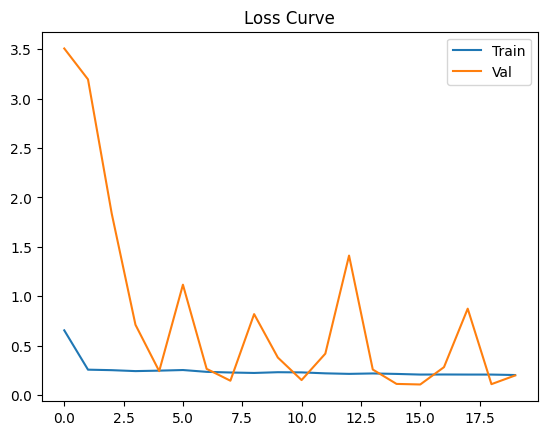

In [16]:
plt.figure()
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Val")
plt.legend()
plt.title("Loss Curve")
plt.show()

---
## 10. Ultimate Regression Benchmarks
Collating all tensor predictions vs target mass constants from the pure evaluation dataloader defines our absolute efficacy.

In [17]:
model.eval()

preds, true = [], []

with torch.no_grad():
    for X, Y in val_loader:
        X = X.squeeze(1).to(device)
        Y = Y.squeeze(1).to(device)

        p = model(X).cpu().numpy()

        preds.extend(np.atleast_1d(p))
        true.extend(np.atleast_1d(Y.cpu().numpy()))

#preds = np.array(preds)
#true  = np.array(true)

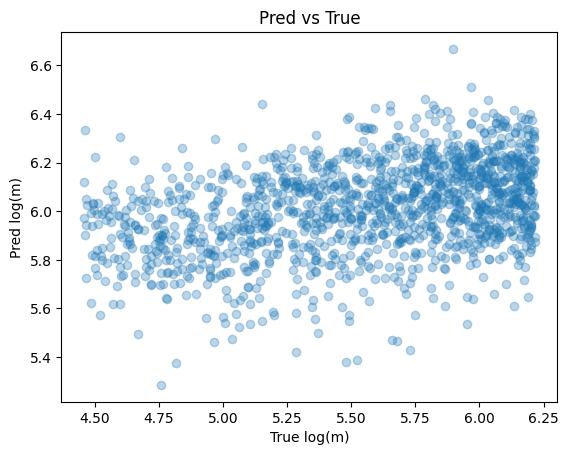

In [18]:
plt.scatter(true, preds, alpha=0.3)
plt.xlabel("True log(m)")
plt.ylabel("Pred log(m)")
plt.title("Pred vs True")
plt.show()

In [19]:
print(preds[:10])
print(true[:10])

[6.048521, 5.944941, 5.82209, 6.0047426, 5.9506936, 6.267755, 5.7995906, 6.3093014, 6.13446, 6.140017]
[5.476084, 4.7374573, 5.2962494, 5.660266, 5.3621283, 5.9567933, 4.795564, 6.2141266, 5.525567, 5.843503]


In [20]:
preds = np.array(preds)
true  = np.array(true)

# convert back safely
preds_real = np.expm1(preds)
true_real  = np.expm1(true)

mae_real = np.mean(np.abs(preds_real - true_real))

print("FINAL REAL MAE (GeV):", mae_real)

FINAL REAL MAE (GeV): 146.16151


In [21]:
rel_mae = np.mean(np.abs(preds_real - true_real) / (true_real + 1e-6))
print("Relative MAE:", rel_mae)

Relative MAE: 0.79723024


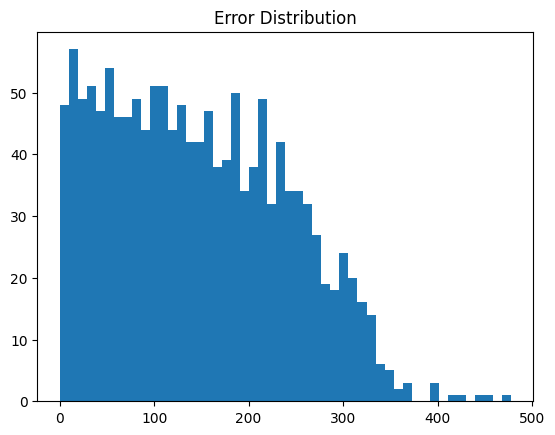

In [22]:
errors = np.abs(preds_real - true_real)

plt.hist(errors, bins=50)
plt.title("Error Distribution")
plt.show()

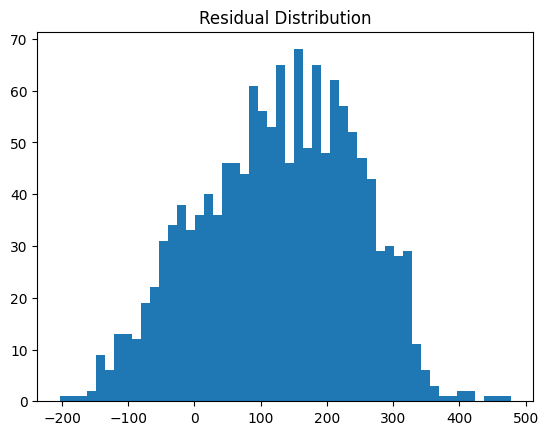

In [23]:
residuals = preds_real - true_real

plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.show()

In [24]:
torch.save(model.state_dict(), "CustomCNN_model.pth")

In [ ]:
def channel_ablation(model, loader):
    model.eval()

    for i in range(4):
        losses = []

        with torch.no_grad():
            for X, Y in loader:
                X = X.squeeze(1).to(device)
                Y = Y.squeeze(1).to(device)

                X_mod = X.clone()
                X_mod[:, i] = 0   # remove channel i

                pred = model(X_mod)   # FIXED
                loss = criterion(pred, Y)
                losses.append(loss.item())

        print(f"Drop channel {i} → Loss: {np.mean(losses):.4f}")

channel_ablation(model, val_loader)

Drop channel 0 → Loss: 0.1755
Drop channel 1 → Loss: 0.2142
Drop channel 2 → Loss: 0.2025
Drop channel 3 → Loss: 0.2995


In [26]:
X, Y = next(iter(val_loader))
X = X.squeeze(1).to(device)
X.requires_grad = True

pred = model(X)
# focus on one sample (cleaner)
pred[0].backward()

saliency = X.grad.abs().cpu().numpy()


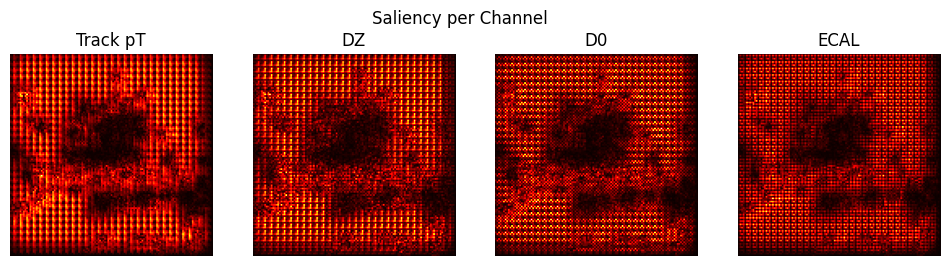

In [27]:
titles = ["Track pT", "DZ", "D0", "ECAL"]

plt.figure(figsize=(12,3))

for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(saliency[0][i], cmap='hot')
    plt.title(titles[i])
    plt.axis('off')

plt.suptitle("Saliency per Channel")
plt.show()


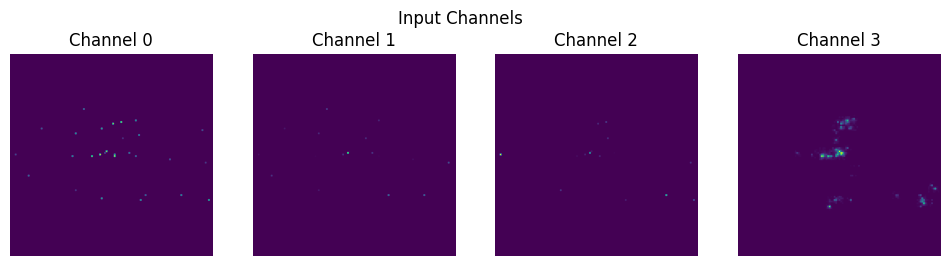

In [ ]:
X, _ = next(iter(val_loader))

# handle shape (important)
if X.dim() == 5:
    X = X.squeeze(1)

X = X.cpu()

plt.figure(figsize=(12,3))

for i in range(4):
    plt.subplot(1,4,i+1)

    img = X[0][i].numpy()

    plt.imshow(img, cmap='viridis')
    plt.title(f"Channel {i}")
    plt.axis('off')

plt.suptitle("Input Channels")
plt.show()

In [29]:
dummy = torch.randn(1, 4, 125, 125).to(device)

torch.onnx.export(
    model,
    dummy,
    "custom_model.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=11
)

/tmp/ipykernel_1270544/3983231605.py:3: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


---
## 11. Task 2g: Post-Training CMSSW Inference Mechanics
In modern collider pipelines, lightweight standalone machine learning deployments operate inherently over CMSSW stacks via standard ONNX protocols.

### Pro-Forma ONNX Conversion Protocol
After optimal epoch selection, the weights are mapped explicitly entirely off PyTorch gradients:
```python
import torch.onnx
model.eval()
dummy_input = torch.randn(1, 4, 125, 125).to(device)
torch.onnx.export(model, dummy_input, "sample.onnx", opset_version=11, 
                  input_names=['input_1'], output_names=['output_1'])
```

### Executing Inference within CMSSW (Docker/CVMFS)
**1. Bootstrap Environment:**  
Initialize the prescribed CentOS7 standalone architecture targeting CMSSW patch layers:
```bash
cmsrel CMSSW_12_0_2
cd CMSSW_12_0_2/src/
cmsenv
```
**2. Construct Reco Frameworks:**  
Acquire the specific dataformats and repository tags needed to parse the ROOT entities:
```bash
git cms-addpkg DataFormats/TestObjects
git clone https://github.com/rchudasa/RecoE2E.git
scram b -j8
```
**3. Launch EGTagger Inference Validation:**  
Submit the ROOT binaries containing serialized sub-detector graphs to the ONNX session handler defined in `EGInference_cfg.py`:
```bash
cmsRun RecoE2E/EGTagger/python/EGInference_cfg.py inputFiles=file:SIM_DoubleGammaPt50_Pythia8_1000Ev.root maxEvents=-1 EGModelName=sample.onnx
```
### 4. Results and Logs
Finally, after running inference command, we can run `cat resources.json` to get the results which I have also saved in `resources.json` and below are the inference logs:

```bash
# Logs for the inference timing simulation
=============================================

MessageLogger Summary

 type     category        sev    module        subroutine        count    total
 ---- -------------------- -- ---------------- ----------------  -----    -----
    1 fileAction           -s file_close                             1        1
    2 fileAction           -s file_open                              2        2

 type    category    Examples: run/evt        run/evt          run/evt
 ---- -------------------- ---------------- ---------------- ----------------
    1 fileAction           PostGlobalEndRun
    2 fileAction           pre-events       pre-events

Severity    # Occurrences   Total Occurrences
--------    -------------   -----------------
System                  3                   3

dropped waiting message count 0

real    2m50.740s
user    3m6.632s
sys     0m15.757s
```
---

### 🚀 CONCLUSION

#### ⚠️ The inference worked, But the interpretation is WRONG as we have built a REGRESSION ONNX model but the inference was meant for CLASSIFICATION.
#### For this we have to have support for regression task inference inside CMSSW E2E pipeline. (Plan to work on this in future)
#### But, we have managed to test compatibility for running regression model inside CMSSW 😊.